In [1]:
#!/usr/bin/env python
"""
netmap GRN analysis pipeline (CLI).

Combines the exploratory notebook (blood case-study, cell-type-mapping,
regulon/marker diagnostics) with the batch/argparse version of the same
analysis, so the whole thing can be run from the command line for any
experiment / cell-type set.

Example:
    python run_netmap_analysis.py \
        --adata_raw /data/.../bd-rhap-rep2_with_markers.h5ad \
        --collectri /data/.../collectri.tsv \
        --results_dir /data/.../case_studies/blood \
        --analysis_dir /data/.../results/case_studies/blood \
        --experiment_name bd-rhap-rep2-markers \
        --apply_ct_mapping \
        --extra_plots
"""

# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
import os
import os.path as op
import sys
import argparse
from itertools import combinations
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.sparse as scs
from matplotlib import pyplot as plt

from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
from netmap.downstream.regulon import *
from netmap.downstream.celltype_random_walk import *

from netmap.plotting.pienet import *
from netmap.plotting.grn_scatter import *
from netmap.plotting.entropy import *
from netmap.plotting.regulon_dotplot import *
from netmap.plotting.tf_subgraph import *

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *

# Raw -> display cell-type label mapping used in the original blood
# case-study notebook. Only applied when --apply_ct_mapping is passed.
DEFAULT_CT_MAPPING = {
    "b_cells": "B cell",
    "cd14+_monocytes": "CD14+ Mono",
    "cd14-_monocytes": "CD14- Mono",
    "cd4+_tcells": "CD4+ T cell",
    "cd8+_tcells": "CD8+ T cell",
    "DC": "DC",
    "pDC": "pDC",
    "nk_cells": "NK cell",
    'megakaryocytes': 'Megakaryocytes'
}

# Marker genes used for the optional random-walk cell-type validation.
DEFAULT_MARKER_DICT = {
    "B cell": ["CD19", "CD79A", "CD21", "MS4A1", "PAX5"],
    "CD4 T cell": ["CD4"],
    "CD8 T cell": ["CD8A", "CD8B", "GZMA", "GZMK"],
    "NK cell": ["NKG7", "NCAM1", "FCGR3A", "GZMB"],
    "CD14 monocyte": ["VCAN", "S100A8", "S100A9"],
    "CD16 monocyte": ["FCGR3A", "CDKN1C"],
    "DC": ["CD1C", "CST3", "FLT3"],
    "pDC": ["PTCRA", "SMIM5", "LAMP5", "JCHAIN"],
}

def save_clustering_score_to_yaml(analysis_output_dir, score):
    with open(op.join(analysis_output_dir, "clustering_score.yaml"), "w") as fh:
        yaml.dump({"clustering_score": float(score)}, fh, default_flow_style=False)


In [2]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/bd-rhap-rep2/bd-rhap-rep2_with_markers.h5ad')
experiment_name = 'bd-rhap-rep2-markers'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/netmap/case_studies/blood/{experiment_name}"
# This is where the GRN files are stored.
output_dir_grn = Path(op.join(output_dir, "grn"))


In [3]:
adata_raw.obs["celltype_semi_manual"] = (
    adata_raw.obs["celltype_semi_manual"].map(DEFAULT_CT_MAPPING)
)

var = pd.read_csv(op.join(output_dir, f"{experiment_name}_var.tsv"))
obs = pd.read_csv(op.join(output_dir, f"{experiment_name}_obs.tsv"))

grn_adata = ad.AnnData(shape=(obs.shape[0], var.shape[0]), var=var, obs=obs)
grn_adata.obs["celltype_semi_manual"] = adata_raw.obs["celltype_semi_manual"].values

print('Loading data')
grn_adata = retrieve_top_edges(grn_adata, output_dir_grn, percentage=0.1)
grn_adata.var = grn_adata.var.set_index("index")


Loading data


In [4]:
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"
os.makedirs(analysis_output_dir, exist_ok=True)
# ---- GEX vs GRN clustering diagnostics --------------------------------
with plt.rc_context():
    sc.pl.umap(adata_raw, color=["celltype_semi_manual", "leiden"], show=False)
    plt.savefig(op.join(analysis_output_dir, "gex_clustering_annotation_umap.pdf"),
                bbox_inches="tight")
    plt.close()

print('Embedding')
sc.tl.pca(grn_adata, svd_solver="randomized", zero_center=False)
sc.pp.neighbors(grn_adata, n_neighbors=15)
sc.tl.umap(grn_adata, n_components=50)
sc.tl.tsne(grn_adata)


Embedding


In [5]:
sc.tl.leiden(grn_adata, resolution=0.28)
score, mapping = unify_group_labelling(
    adata_raw, grn_adata, "celltype_semi_manual", "leiden", True
)
print(score)
save_clustering_score_to_yaml(analysis_output_dir, score)



0.9807091066320761


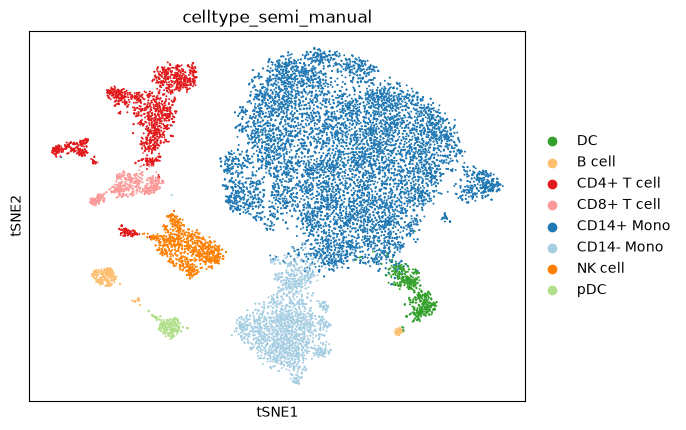

In [41]:
pal =   {'CD14+ Mono': (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),  
'CD14- Mono': (0.6509803921568628, 0.807843137254902, 0.8901960784313725), 
'CD4+ T cell' : (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 'CD8+ T cell': (0.984313725490196, 0.6039215686274509, 0.6),
  'B cell': (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
   'NK cell': (1.0, 0.4980392156862745, 0.0),
   'pDC': (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
   'DC':(0.2, 0.6274509803921569, 0.17254901960784313)}
sc.pl.tsne(grn_adata, color=[ "celltype_semi_manual"], palette=pal)



In [ ]:

grn_adata.obs.loc[:, ["leiden", "celltype_semi_manual", 'leiden_remap']].to_csv(op.join(analysis_output_dir, 'leiden_remap.tsv'), sep = '\t')
pd.DataFrame(grn_adata.obsm["X_tsne"]).to_csv(op.join(analysis_output_dir, 'tsne_embedding.tsv'), sep = '\t')
pd.DataFrame(grn_adata.obsm["X_pca"]).to_csv(op.join(analysis_output_dir, 'pca_embedding.tsv'), sep = '\t')

In [ ]:

## Redo the probablistic celltype assignment with more markers for cd4+ cells


In [2]:
# Marker genes used for the optional random-walk cell-type validation.
DEFAULT_MARKER_DICT = {
    "B cell": ["CD19", "CD79A", "CD21", "MS4A1", "PAX5"],
    "CD4+ T cell": ["CD4", 'TCF7', 'LEF1','ITGB1' ],
    "CD8+ T cell": ["CD8A", "CD8B", "GZMA", "GZMK"],
    "NK cell": ["NKG7", "NCAM1", "FCGR3A", "GZMB"],
    "CD14+ Mono": ["VCAN", "S100A8", "S100A9"],
    "CD14- Mono": ["FCGR3A", "CDKN1C"],
    "DC": ["CD1C", "CST3", "FLT3"],
    "pDC": ["PTCRA", "SMIM5", "LAMP5", "JCHAIN"],
}
pal =   {'CD14+ Mono': (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),  
'CD14- Mono': (0.6509803921568628, 0.807843137254902, 0.8901960784313725), 
'CD4+ T cell' : (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 'CD8+ T cell': (0.984313725490196, 0.6039215686274509, 0.6),
  'B cell': (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
   'NK cell': (1.0, 0.4980392156862745, 0.0),
   'pDC': (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
   'DC':(0.2, 0.6274509803921569, 0.17254901960784313)}



In [3]:
experiment_name = 'bd-rhap-rep2-markers'

analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"


In [4]:
grn_adata3 =  sc.read_h5ad(op.join(analysis_output_dir, 'bd-rhap-rep2-markers_processed.h5ad'))
#grn_adata3.obs['celltype_semi_manual'] = grn_adata3.obs['celltype_semi_manual'].cat.remove_categories('Megakaryocytes')

In [5]:
# Marker-based cell-type validation via random walk
proba, celltypes, tgpc = run_celltype_random_walk(
    grn_adata3, DEFAULT_MARKER_DICT, restart_prob=0.2, n_jobs=8, max_iter=100,
    edge_idf=True, scale_by_marker_count=True, idf_log_scale=True, top_genes_k=20,
)
grn_adata3.obsm["celltype_rw_proba"] = proba
grn_adata3.uns["celltype_rw_labels"] = celltypes
grn_adata3.obs["celltype_rw_pred"] = np.array(celltypes)[proba.argmax(axis=1)]

rw_cross_tab = pd.crosstab(
    grn_adata3.obs["celltype_semi_manual"], grn_adata3.obs["celltype_rw_pred"]
)



Dropped 3 marker gene(s) not present in the GRN gene universe.


[[0.00273966 0.00212962 0.         ... 0.         0.         0.00532793]
 [0.         0.002748   0.         ... 0.         0.         0.00494   ]
 [0.         0.         0.         ... 0.         0.         0.00482244]
 ...
 [0.         0.00290109 0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.00417584 0.00484466]
 [0.00205688 0.00223889 0.         ... 0.         0.         0.00445012]]


In [6]:
rw_cross_tab.to_csv(op.join(analysis_output_dir, "celltype_rw_crosstab.tsv"), sep="\t")


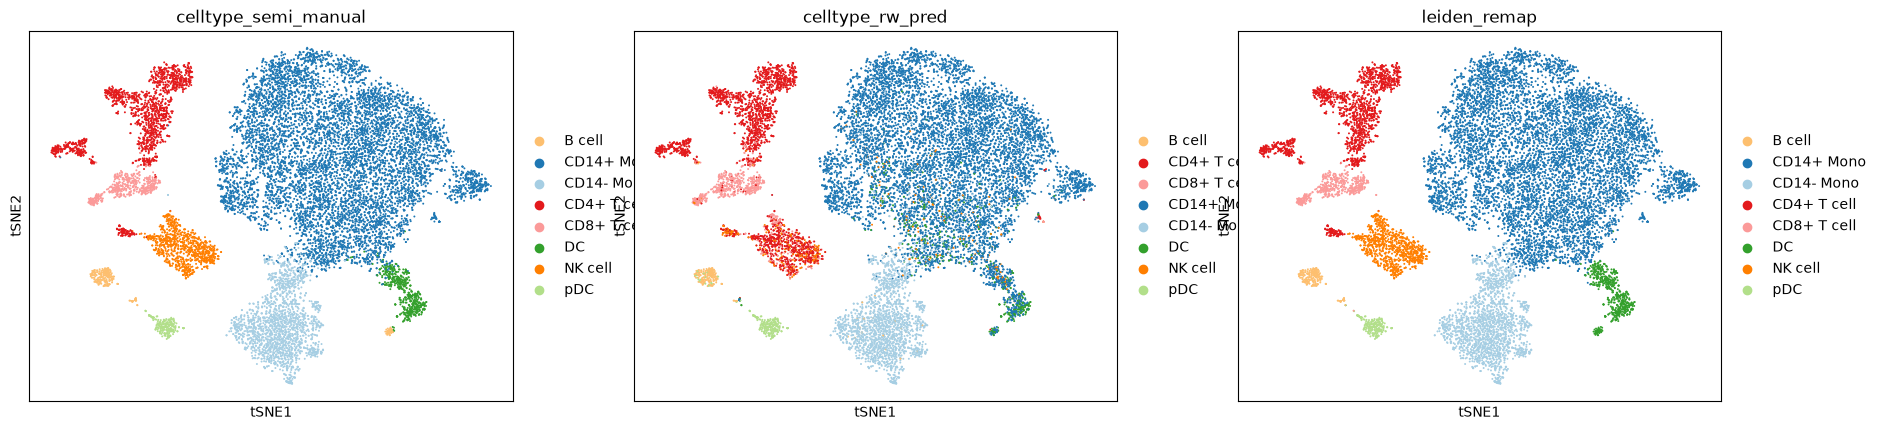

In [7]:
sc.pl.tsne(grn_adata3, color=[ 'celltype_semi_manual', "celltype_rw_pred", 'leiden_remap' ], palette=pal)


In [8]:
grn_adata3.write_h5ad(op.join(analysis_output_dir, 'bd-rhap-rep2-markers_processed.h5ad'))


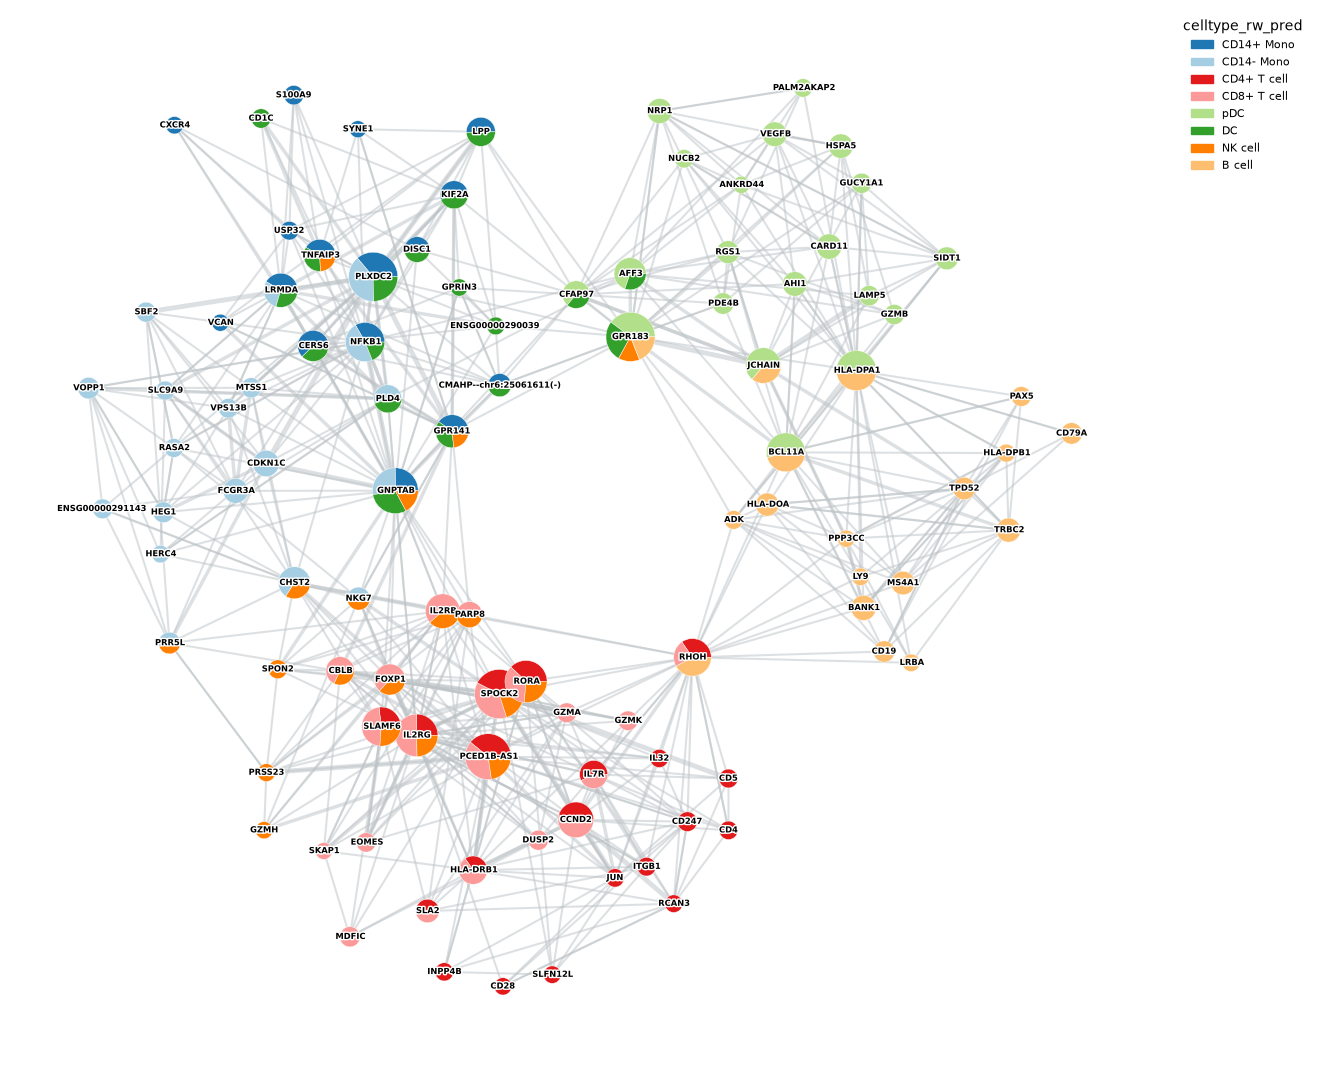

In [9]:


# Combined cell-type co-expression network
network = compute_combined_celltype_network(
    grn_adata3, tgpc, celltype_col='celltype_rw_pred', top_n=30,
    max_nodes_per_celltype=20, top_edges_per_celltype=100,
)
fig, _ = plot_combined_celltype_network(
    network, k=0.5, seed=1, node_radius_frac=(0.005, 0.025),
    palette=pal, figsize=(15, 15), layout="kk", drop_isolates=True,
)


importance = pd.DataFrame({"importance": network['importance']})
fractions = pd.DataFrame(network['gene_fractions']).T
fractions = pd.concat([importance, fractions], axis = 1)
fractions.sort_values('importance', ascending=False)
fractions.to_csv(op.join(analysis_output_dir, f"{experiment_name}_fractions.tsv"), sep = '\t')



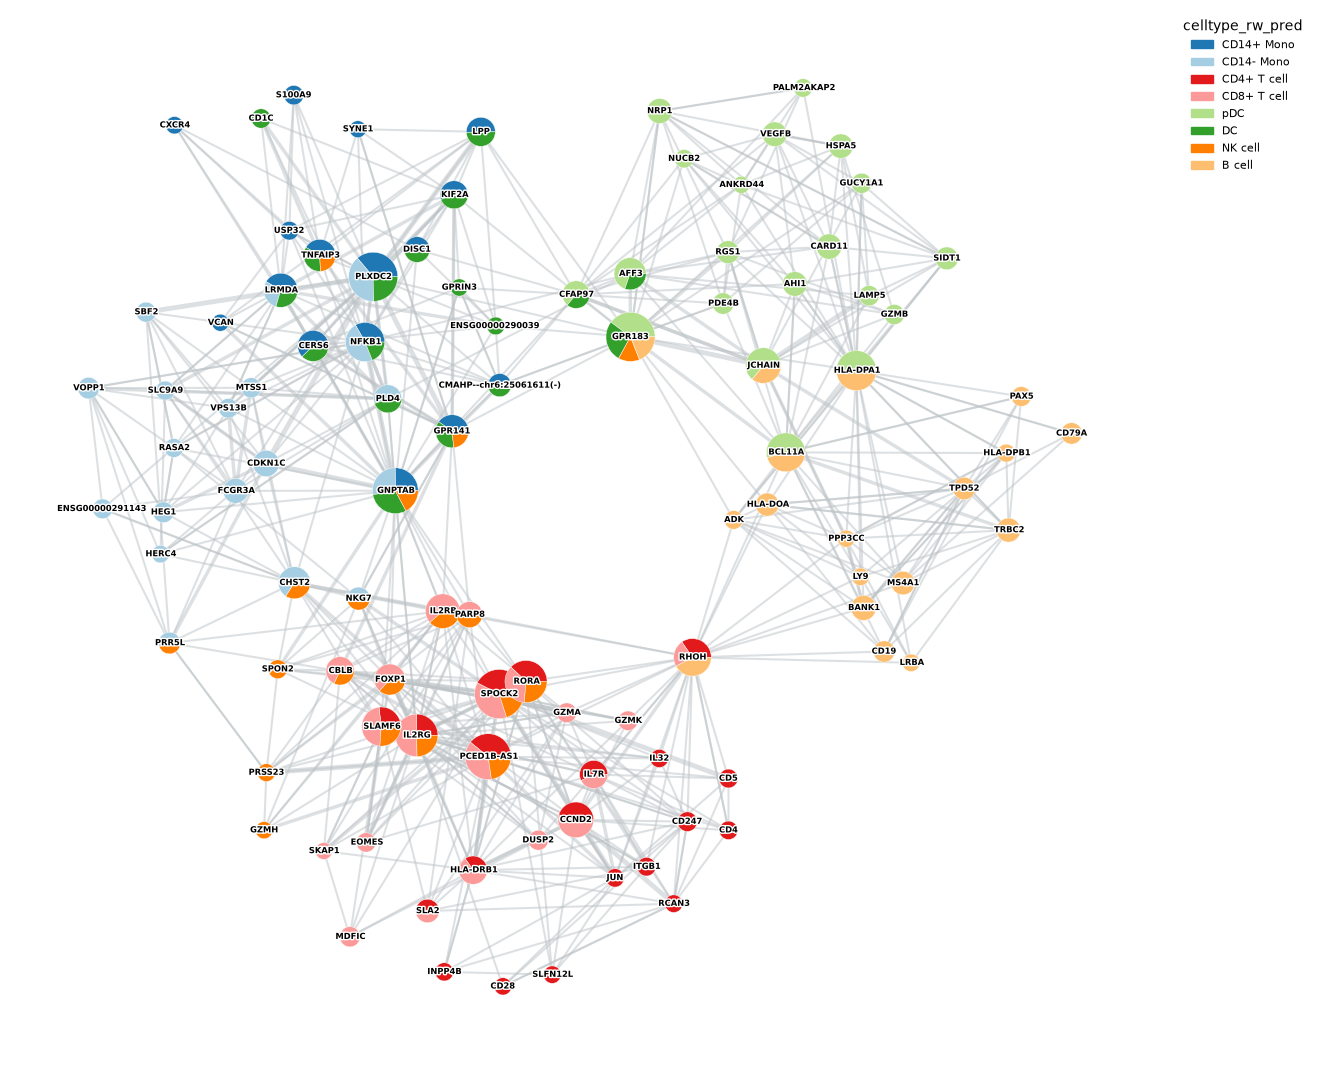

In [10]:
fig